### Imports

In [1]:
import os
import dill
import json
import yaml
import string
import itertools
from tqdm import trange
from pathlib import Path

import torch
import scipy.stats
import numpy as np
import pandas as pd

import sys
sys.path.append("..")

from utils import print_time_slices

from cdt.metrics import SHD

import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng()

def prind(di): print(json.dumps(di, sort_keys=False, indent=4))

COL_NAMES = list(string.ascii_uppercase) + ["".join(a) for a in list(itertools.permutations(list(string.ascii_uppercase), r=2))]

Detecting 1 CUDA device(s).


### Causal Discovery

#### Data

##### Synthetic

In [2]:
# data_folder = 'variables'
# folder_size = 'medium'
# exp_archive_path = Path(".").resolve().parents[1] / "data" / "results" / "archive" / data_folder / folder_size
# lcm_archive_path = Path(".").resolve().parents[1] / "data" / "results" / "archive" / "with_lcm" / data_folder / folder_size
# data_path = list(Path(".").resolve().parents)[1] / 'data' / 'synthetic' / data_folder / folder_size

# # data pairs
# data_n_arch = []
# for ind, fn in enumerate(os.listdir(data_path / "data")[:]):
#     true_data = pd.read_csv(data_path / "data" / fn)
#     true_graph = torch.load(data_path / "structure" / fn.replace("ts", "struct").replace("csv", "pt"))
#     data_n_arch.append([true_data, true_graph, exp_archive_path / f"runs_{ind}", lcm_archive_path / f"runs_{ind}"])

##### fMRI

In [3]:
# # data path
# data_folder = 'fMRI'
# data_path = list(Path(".").resolve().parents)[1] / 'data' / data_folder

# # data pairs
# data_pairs = []
# for fn in os.listdir(data_path / "graphs")[:]:
#     true_data = pd.read_csv(data_path / "timeseries" / fn.replace("sim", "timeseries").replace("_gt_processed", ""))
#     true_graph = from_fmri_to_cp(test_fmri=true_data, label_fmri=pd.read_csv(data_path / "graphs" / fn, names=['effect', 'cause', 'delay']))
#     data_pairs.append([true_data, true_graph])
#     # # inspect
#     # print(f"- {fn}")
#     # print_time_slices(true_graph)
#     # print()

#### Methods

In [2]:
# from simulation.simulation_tools import get_optimal_sim_XY, get_optimal_sim_XYP
from simulation.simulation_tools import archive_sparsity_penalty
from utils import estimate_with_PCMCI
from cd_methods.DynoTears.utils import estimate_with_DYNOTEARS

# methods
CD_METHODS = {
    "PCMCI": estimate_with_PCMCI,
    "DYNO": estimate_with_DYNOTEARS,
    # "CP": estimate_with_CP,
    # "LCM": estimate_with_LCM
}

# kwargs
CD_KWARGS = {
    "PCMCI": {
        'n_lags': 2, 
        "n_reps": 10
    },
    "DYNO": {
        "n_lags": 2, 
        "lambda_w": 0.1,
        "lambda_a": 0.1, 
        "max_iter": 100,
        "n_reps": 10,
        "thresholded": True,
        "threshold": 0.05
    },
    # "CP": {
    #     "model": None,
    #     "model_name": None,
    #     "MAX_VAR": 12,
    #     "thresholded": True,
    #     "threshold": 0.25
    # }, 
    # "LCM": {
    #     "model": "../cd_methods/lcm_mini/logs/plain_100k_2c5M_20E_01_27/last.ckpt",
    #     "thresholded": True,
    #     "threshold": 0.25
    # }
}

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.
Loaded PyTorch TimesFM, likely because python version is 3.10.9 (tags/v3.10.9:1dd9be6, Dec  6 2022, 20:01:21) [MSC v.1934 64 bit (AMD64)].


#### Calls

In [8]:
# utility functions
def fix_lag_dim(a_graph, b_graph):
    if  a_graph.shape[2]>b_graph.shape[2]:
        b_graph = torch.nn.functional.pad(input=b_graph, pad=(a_graph.shape[2] - b_graph.shape[2], 0, 0, 0, 0, 0), value=0)
    if  b_graph.shape[2]>a_graph.shape[2]:
        a_graph = torch.nn.functional.pad(input=a_graph, pad=(b_graph.shape[2] - a_graph.shape[2], 0, 0, 0, 0, 0), value=0)
    return a_graph, b_graph

def get_archive_optimal(archive, true_graph):
    shd_per_config = []
    for i in range(len(archive['fit_scm_list'])):
        t_graph = true_graph.clone()
        p_graph = archive['fit_scm_list'][i].causal_structure.causal_structure_cp.clone()
        t_graph, p_graph = fix_lag_dim(t_graph, p_graph)
        shd_per_config.append(SHD(target=t_graph.numpy(), pred=p_graph.numpy()))
    return min(shd_per_config)

def get_tpe(label_graph):
    return label_graph.shape[0]**2 * (label_graph.shape[2])

def get_shd_variants(true_graph, pred_graph, opt_shd):
    nvars = true_graph.shape[0] * true_graph.shape[2]
    shd = SHD(target=true_graph.numpy(), pred=pred_graph.numpy())
    nshd = round(shd / get_tpe(true_graph), 2)
    dshd = shd - opt_shd
    vshd = round(shd / nvars, 2)
    dvshd = round(vshd - (opt_shd / nvars), 2)
    return shd, nshd, dshd, vshd, dvshd

# subfolders
data_batch = 'batch_2'
archive_sf = 'archive_newer_full'
save_sf = 'iter_b2f_l2'

# folders and sizes
folders = ['variables', 'samples', 'density', 'lags']
sizes = ['small', 'medium', 'large']

for i, data_folder in enumerate(folders[:]):
    for j, folder_size in enumerate(sizes[:]):

        # paths
        print(f"\n === Folder: {data_folder} | Size: {folder_size} === ")
        exp_archive_path = Path(".").resolve().parents[1] / "data" / "results" / "archive" / archive_sf / data_folder / folder_size
        data_path = list(Path(".").resolve().parents)[1] / 'data' / 'synthetic' / data_batch / data_folder / folder_size

        # data pairs
        data_n_arch = []
        for ind, fn in enumerate(os.listdir(data_path / "data")[:]):
            true_data = pd.read_csv(data_path / "data" / fn)
            true_graph = torch.load(data_path / "structure" / fn.replace("ts", "struct").replace("csv", "pt"))
            data_n_arch.append([true_data, true_graph, exp_archive_path / f"runs_{ind}"])

        # placeholders
        results = {k: pd.DataFrame(index=range(len(data_n_arch)), columns=list(CD_METHODS.keys()) + ["ACT"]) 
                   for k in ["shd", "nshd", "dshd", "vshd", "dvshd"]}

        for ind, (true_data, label_graph, arch_path) in enumerate(data_n_arch[:]):
            print(f"\n--- {ind} ---")
            tpe = get_tpe(label_graph)
            print(f"Graph shape: {label_graph.numpy().shape} | Total possible edges: {tpe}")

            # ACT
            method_name = "ACT"
            try:
                fn = os.listdir(arch_path)[0]
                with open(arch_path / fn, "rb") as f:
                    archive = dill.load(f)
                archive = archive_sparsity_penalty(archive, a=0.05, n=100)
                idx = archive['idx']
                opt_shd = get_archive_optimal(archive=archive, true_graph=label_graph.clone())
                true_graph = label_graph.clone()
                pred_graph = archive['fit_scm_list'][idx].causal_structure.causal_structure_cp.clone()
                true_graph, pred_graph = fix_lag_dim(true_graph, pred_graph)
                shd, nshd, dshd, vshd, dvshd = get_shd_variants(true_graph=true_graph, pred_graph=pred_graph, opt_shd=opt_shd)
                print(f"- {method_name} : shd={shd}, nshd={nshd}, dshd={dshd}, vshd={vshd}, dvshd={dvshd}")
            except:
                print(f"- Error with ACT on ind {ind}. Setting SHD & nSHD to NaN.")
                shd = np.nan
                nshd = np.nan
                dshd = np.nan
                vshd = np.nan
                dvshd = np.nan
            results["shd"].loc[ind, method_name] = shd
            results["nshd"].loc[ind, method_name] = nshd
            results["dshd"].loc[ind, method_name] = dshd
            results["vshd"].loc[ind, method_name] = vshd
            results["dvshd"].loc[ind, method_name] = dvshd

            # baseline methods
            for method_name in CD_METHODS.keys():
                try:
                    true_graph = label_graph.clone()
                    # NOTE: decided to keep this always off for a fair comparison
                    # if "n_lags" in CD_KWARGS[method_name].keys():
                    #     CD_KWARGS[method_name]["n_lags"] = true_graph.shape[2]
                    try:
                        pred_graph, _ = CD_METHODS[method_name](true_data=true_data, **CD_KWARGS[method_name])
                    except Exception as e:
                        if str(e)=="ValueError: PCMCI was not able to find a valuable solution - no edges were discovered.":
                            pred_graph = torch.zeros_like(input=true_graph)
                    # compute SHD & variants
                    true_graph, pred_graph = fix_lag_dim(true_graph, pred_graph)
                    shd, nshd, dshd, vshd, dvshd = get_shd_variants(true_graph=true_graph, pred_graph=pred_graph, opt_shd=opt_shd)
                    print(f"- {method_name} : shd={shd}, nshd={nshd}, dshd={dshd}, vshd={vshd}, dvshd={dvshd}")
                except:
                    print(f"- Error with method {method_name} on ind {ind}. Setting SHD & nSHD to NaN.")
                    shd = np.nan
                    nshd = np.nan
                    dshd = np.nan
                    vshd = np.nan
                    dvshd = np.nan
                results["shd"].loc[ind, method_name] = shd
                results["nshd"].loc[ind, method_name] = nshd
                results["dshd"].loc[ind, method_name] = dshd
                results["vshd"].loc[ind, method_name] = vshd
                results["dvshd"].loc[ind, method_name] = dvshd

        save_fn = f"cd-task_{data_folder}_{folder_size}"
        for k, res in results.items():
            save_path = list(Path(".").resolve().parents)[1] / 'data' / 'results' / 'cd_task' / save_sf / k 
            os.makedirs(save_path, exist_ok=True)
            res.to_csv(save_path / f'{save_fn}.csv', index=False)


 === Folder: variables | Size: small === 

--- 0 ---
Graph shape: (5, 5, 2) | Total possible edges: 50
LOG: Optimal Simulation: Sparsity Penalty: optimal case: idx=11 | auc=0.5833333333333333 | edges=7.0


100%|██████████| 100/100 [00:00<00:00, 763.34it/s]


LOG: Optimal Simulation: Sparsity Penalty: eq. found: idx=6 | auc=0.5946655610834716 | edges=7.0


100%|██████████| 100/100 [00:00<00:00, 770.29it/s]


LOG: Optimal Simulation: Sparsity Penalty: eq. found: idx=10 | auc=0.6160171365395246 | edges=7.0


...

LOG: Optimal Simulation: Sparsity Penalty: opti case: idx=11 | auc=0.5146144278606966 | edges=9.0
- ACT : shd=17.0, nshd=0.06, dshd=0.0, vshd=0.57, dvshd=0.0
- PCMCI : shd=20.0, nshd=0.07, dshd=3.0, vshd=0.67, dvshd=0.1
- DYNO : shd=43.0, nshd=0.14, dshd=26.0, vshd=1.43, dvshd=0.86

--- 9 ---
Graph shape: (10, 10, 3) | Total possible edges: 300
LOG: Optimal Simulation: Sparsity Penalty: optimal case: idx=10 | auc=0.4504560530679934 | edges=9.0


100%|██████████| 100/100 [00:00<00:00, 929.48it/s]


LOG: Optimal Simulation: Sparsity Penalty: eq. found: idx=11 | auc=0.5731066887783305 | edges=9.0


100%|██████████| 100/100 [00:00<00:00, 960.76it/s]


LOG: Optimal Simulation: Sparsity Penalty: opti case: idx=10 | auc=0.4504560530679934 | edges=9.0
- ACT : shd=20.0, nshd=0.07, dshd=0.0, vshd=0.67, dvshd=0.0
- PCMCI : shd=23.0, nshd=0.08, dshd=3.0, vshd=0.77, dvshd=0.1
- DYNO : shd=49.0, nshd=0.16, dshd=29.0, vshd=1.63, dvshd=0.96


#### Debug

In [3]:
def fix_lag_dim(a_graph, b_graph):
    if  a_graph.shape[2]>b_graph.shape[2]:
        b_graph = torch.nn.functional.pad(input=b_graph, pad=(a_graph.shape[2] - b_graph.shape[2], 0, 0, 0, 0, 0), value=0)
    if  b_graph.shape[2]>a_graph.shape[2]:
        a_graph = torch.nn.functional.pad(input=a_graph, pad=(b_graph.shape[2] - a_graph.shape[2], 0, 0, 0, 0, 0), value=0)
    return a_graph, b_graph

def get_archive_optimal(archive, true_graph):
    shd_per_config = []
    for i in range(len(archive['fit_scm_list'])):
        t_graph = true_graph.clone()
        p_graph = archive['fit_scm_list'][i].causal_structure.causal_structure_cp.clone()
        t_graph, p_graph = fix_lag_dim(t_graph, p_graph)
        shd_per_config.append(SHD(target=t_graph.numpy(), pred=p_graph.numpy()))
    return min(shd_per_config)

def get_tpe(label_graph):
    return label_graph.shape[0]**2 * (label_graph.shape[2])

def get_shd_variants(true_graph, pred_graph, opt_shd):
    nvars = true_graph.shape[0] * true_graph.shape[2]
    shd = SHD(target=true_graph.numpy(), pred=pred_graph.numpy())
    nshd = round(shd / get_tpe(true_graph), 2)
    dshd = shd - opt_shd
    vshd = round(shd / nvars, 2)
    dvshd = round(vshd - (opt_shd / nvars), 2)
    return shd, nshd, dshd, vshd, dvshd

# subfolders
data_batch = 'batch_2'
archive_sf = 'archive_newer_full'

# folders and sizes
folders = ['density']
sizes = ['small']

for i, data_folder in enumerate(folders[:]):
    for j, folder_size in enumerate(sizes[:]):

        # paths
        print(f"\n === Folder: {data_folder} | Size: {folder_size} === ")
        exp_archive_path = Path(".").resolve().parents[1] / "data" / "results" / "archive" / archive_sf / data_folder / folder_size
        data_path = list(Path(".").resolve().parents)[1] / 'data' / 'synthetic' / data_batch / data_folder / folder_size

        # data pairs
        data_n_arch = []
        for ind, fn in enumerate(os.listdir(data_path / "data")[:]):
            true_data = pd.read_csv(data_path / "data" / fn)
            true_graph = torch.load(data_path / "structure" / fn.replace("ts", "struct").replace("csv", "pt"))
            data_n_arch.append([true_data, true_graph, exp_archive_path / f"runs_{ind}"])

        # placeholders
        results = {k: pd.DataFrame(index=range(len(data_n_arch)), columns=list(CD_METHODS.keys()) + ["ACT"]) 
                   for k in ["shd", "nshd", "dshd", "vshd", "dvshd"]}

        for ind, (true_data, label_graph, arch_path) in enumerate(data_n_arch[:]):
            print(f"\n--- {ind} ---")
            tpe = get_tpe(label_graph)
            print(f"Graph shape: {label_graph.numpy().shape} | Total possible edges: {tpe}")
            print(f"LOG: label graph")
            print_time_slices(label_graph)
            for t in range(label_graph.shape[2]):
                print(f" - lag {label_graph.shape[2] - t}: {label_graph[:, :, t].sum()} edges")

            # ACT
            method_name = "ACT"
            try:
                fn = os.listdir(arch_path)[0]
                with open(arch_path / fn, "rb") as f:
                    archive = dill.load(f)
                archive = archive_sparsity_penalty(archive, a=0.05, n=100)
                idx = archive['idx']
                # ...
                shd_per_config = []
                for i in range(len(archive['fit_scm_list'])):
                    t_graph = label_graph.clone()
                    p_graph = archive['fit_scm_list'][i].causal_structure.causal_structure_cp.clone()
                    t_graph, p_graph = fix_lag_dim(t_graph, p_graph)
                    shd_per_config.append(SHD(target=t_graph.numpy(), pred=p_graph.numpy()))
                print(list(enumerate(zip(shd_per_config, [round(x, 2) for x in archive['auc_list']]))))
                opt_shd =  min(shd_per_config)
                opt_shd_i = np.argmin(shd_per_config)
                print(f"LOG: ACT: {idx} | Optimal: {opt_shd_i}")
                #...
                t_graph, p_graph = fix_lag_dim(label_graph.clone(), archive['fit_scm_list'][idx].causal_structure.causal_structure_cp.clone())
                temp_shd = SHD(target=t_graph.numpy(), pred=p_graph.numpy())
                # ...
                # opt_shd = get_archive_optimal(archive=archive, true_graph=label_graph.clone())
                true_graph = label_graph.clone()
                pred_graph = archive['fit_scm_list'][idx].causal_structure.causal_structure_cp.clone()
                print(f"LOG: ACT graph (SHD={temp_shd}) ({archive['cfg_list'][idx]['cd']})")
                print_time_slices(pred_graph)
                print(f"LOG: Opt SHD graph (SHD={opt_shd}) ({archive['cfg_list'][opt_shd_i]['cd']})")
                print_time_slices(archive['fit_scm_list'][opt_shd_i].causal_structure.causal_structure_cp.clone())
                true_graph, pred_graph = fix_lag_dim(true_graph, pred_graph)
                shd, nshd, dshd, vshd, dvshd = get_shd_variants(true_graph=true_graph, pred_graph=pred_graph, opt_shd=opt_shd)
                print(f"- {method_name} : shd={shd}, nshd={nshd}, dshd={dshd}, vshd={vshd}, dvshd={dvshd}")
            except:
                print(f"- Error with ACT on ind {ind}. Setting SHD & nSHD to NaN.")

            # # baseline methods
            # for method_name in CD_METHODS.keys():
            #     try:
            #         true_graph = label_graph.clone()
            #         try:
            #             pred_graph, _ = CD_METHODS[method_name](true_data=true_data, **CD_KWARGS[method_name])
            #         except Exception as e:
            #             if str(e)=="ValueError: PCMCI was not able to find a valuable solution - no edges were discovered.":
            #                 pred_graph = torch.zeros_like(input=true_graph)
            #         # compute SHD & variants
            #         print(f"LOG: {method_name} graph")
            #         print_time_slices(pred_graph)
            #         true_graph, pred_graph = fix_lag_dim(true_graph, pred_graph)
            #         shd, nshd, dshd, vshd, dvshd = get_shd_variants(true_graph=true_graph, pred_graph=pred_graph, opt_shd=opt_shd)
            #         print(f"- {method_name} : shd={shd}, nshd={nshd}, dshd={dshd}, vshd={vshd}, dvshd={dvshd}")
            #     except:
            #         print(f"- Error with method {method_name} on ind {ind}. Setting SHD & nSHD to NaN.")


 === Folder: density | Size: small === 

--- 0 ---
Graph shape: (10, 10, 2) | Total possible edges: 200
LOG: label graph
[[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 1. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 1. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 0. 0. 0. 0. 0. 0. 0.]]
 - lag 2: 9.0 edges
 - lag 1: 14.0 edges
LOG: Optimal Simulation: Sparsity Penalty: optimal case: idx=18 | auc=0.6357103372028744 | edges=27.0


100%|██████████| 100/100 [00:00<00:00, 812.97it/s]


LOG: Optimal Simulation: Sparsity Penalty: eq. found: idx=6 | auc=0.6956882255389718 | edges=10.0


100%|██████████| 100/100 [00:00<00:00, 794.54it/s]


LOG: Optimal Simulation: Sparsity Penalty: eq. found: idx=9 | auc=0.6779988944168048 | edges=10.0


...

LOG: Optimal Simulation: Sparsity Penalty: eq. found: idx=18 | auc=0.5923507462686567 | edges=23.0


100%|██████████| 100/100 [00:00<00:00, 878.73it/s]


LOG: Optimal Simulation: Sparsity Penalty: eq. found: idx=19 | auc=0.5655749032614704 | edges=23.0


100%|██████████| 100/100 [00:00<00:00, 916.64it/s]

LOG: Optimal Simulation: Sparsity Penalty: opti case: idx=2 | auc=0.593698175787728 | edges=5.0
[(0, (15.0, 0.9)), (1, (15.0, 0.9)), (2, (15.0, 0.59)), (3, (15.0, 0.61)), (4, (8.0, 0.92)), (5, (8.0, 0.95)), (6, (8.0, 0.57)), (7, (8.0, 0.54)), (8, (10.0, 0.86)), (9, (10.0, 0.88)), (10, (10.0, 0.61)), (11, (10.0, 0.56)), (12, (27.0, 1.0)), (13, (27.0, 0.99)), (14, (27.0, 0.84)), (15, (27.0, 0.8)), (16, (25.0, 0.99)), (17, (25.0, 0.98)), (18, (25.0, 0.59)), (19, (25.0, 0.57)), (20, (26.0, 0.97)), (21, (26.0, 0.97)), (22, (26.0, 0.63)), (23, (26.0, 0.52))]
LOG: ACT: 2 | Optimal: 4
LOG: ACT graph (SHD=15.0) ({'cd_method': 'PCMCI', 'cd_kwargs': {'n_lags': 1, 'n_reps': 10}})
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 

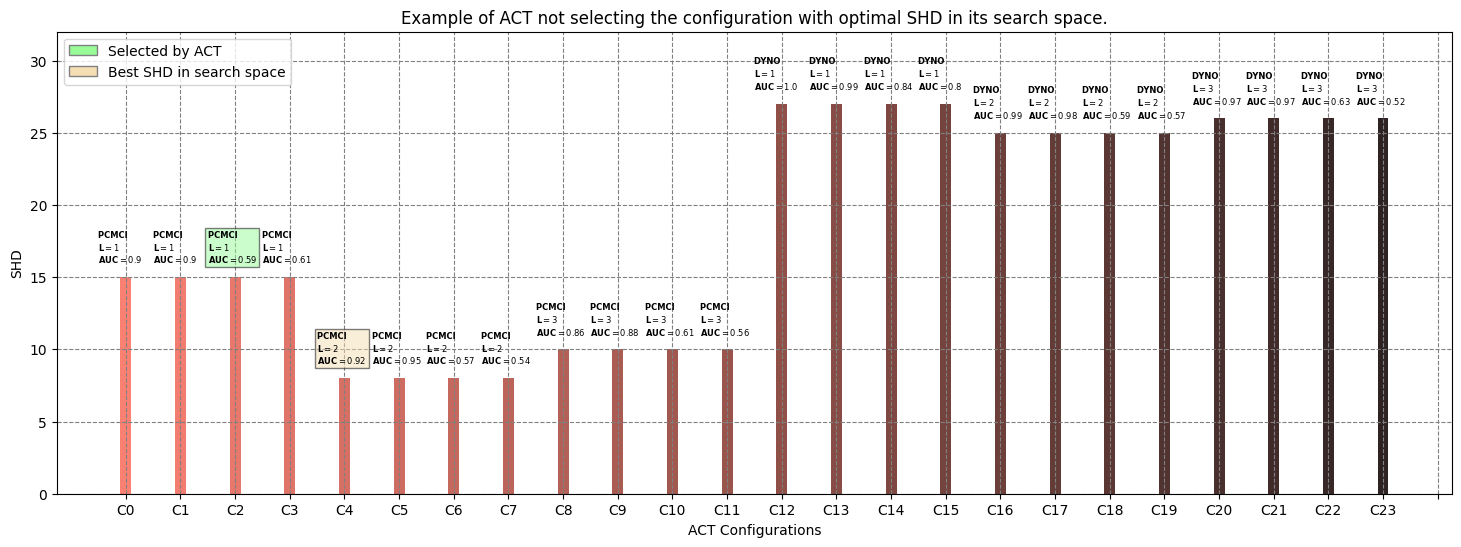

In [4]:
f, ax = plt.subplots(ncols=1, nrows=1, figsize=(18, 6))
colors = sns.color_palette(palette="dark:salmon_r", n_colors=len(archive['cfg_list']))

ax.grid(color='gray', linestyle='dashed')
ax.set_xticks(ticks=[x for x in range(len(archive['cfg_list']) + 1)], labels=[f"C{x}" for x in range(len(archive['cfg_list']))] + [""])
ax.set_ylim((0, max(shd_per_config)+5))
ax.set_xlabel("ACT Configurations")
ax.set_ylabel("SHD")
ax.set_title("Example of ACT not selecting the configuration with optimal SHD in its search space.")
for x, color in zip(range(len(archive['cfg_list'])), colors):
    if x==archive["idx"]:
        text_bbox = dict(boxstyle='square', facecolor='palegreen', alpha=0.5)
    elif x==opt_shd_i:
        text_bbox = dict(boxstyle='square', facecolor='wheat', alpha=0.5)
    else:
        text_bbox = None
    ax.bar(x=x, width=0.2, height=shd_per_config[x], color=color)
    method = archive['cfg_list'][x]['cd']['cd_method']
    lags = archive['cfg_list'][x]['cd']['cd_kwargs']['n_lags']
    auc = round(archive['auc_list'][x], 2)
    s = f"{method} \nL$={lags}$ \nAUC$={auc}$"
    ax.text(x=x-0.5, y=shd_per_config[x]+1, s=s, fontdict={'size': 6, 'fontweight':'bold'}, bbox=text_bbox)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='palegreen', edgecolor='gray', label='Selected by ACT'),
    Patch(facecolor='wheat', edgecolor='gray', label='Best SHD in search space')
]
ax.legend(handles=legend_elements, loc='upper left')

#### Load and visualize results

##### Boxplot

In [ ]:
# folders = ['variables', 'samples', 'density', 'lags']
# sizes = ['small', 'medium', 'large']

# f, ax = plt.subplots(len(folders), len(sizes), figsize=(12, 7), sharex=True, sharey=True)

# for i, data_folder in enumerate(folders[:]):
#     for j, folder_size in enumerate(sizes):
        # load 
        # results = pd.read_csv(Path(".").resolve().parents[1] / 'data' / 'results' / 'cd_task' / f'cd-task_{data_folder}_{folder_size}.csv')
        # results = results.drop(columns=["CP"])
        # display(results)
        # for k, (x, color) in enumerate(zip(results.columns, sns.color_palette("pastel"))):
        #     ax[i, j].errorbar(x=k+1, y=results[x].mean(), yerr=results[x].std(), fmt='o', capsize=5, label=x)
            # ax[i, j].boxplot(results.fillna(results.max())[x], positions=[k+1], widths=0.3, patch_artist=True, 
            #                 boxprops=dict(facecolor=color, color="black", alpha=0.6), medianprops=dict(color="indianred"))
        # ax[i, j].set_ylim(-1, results.max().max() * 1.1)
        # ax[i, j].set_yticks(range(0, int(results.max().max()), 20))
        # ax[i, j].set_xticks(list(range(1, len(results.columns)+1, 1)), results.columns, rotation=0)
        # ax[i, j].set_title(f"{data_folder} - {folder_size}")
        # if j == 0:
        #     ax[i, j].set_ylabel("SHD")
# plt.tight_layout()
# plt.show()

##### $\Delta$ SHD

In [ ]:
# # utility functions
# def fix_lag_dim(a_graph, b_graph):
#     if  a_graph.shape[2]>b_graph.shape[2]:
#         b_graph = torch.nn.functional.pad(input=b_graph, pad=(a_graph.shape[2] - b_graph.shape[2], 0, 0, 0, 0, 0), value=0)
#     if  b_graph.shape[2]>a_graph.shape[2]:
#         a_graph = torch.nn.functional.pad(input=a_graph, pad=(b_graph.shape[2] - a_graph.shape[2], 0, 0, 0, 0, 0), value=0)
#     return a_graph, b_graph

# def get_archive_optimal(archive, true_graph):
#     shd_per_config = []
#     for i in range(len(archive['fit_scm_list'])):
#         t_graph = true_graph.clone()
#         p_graph = archive['fit_scm_list'][i].causal_structure.causal_structure_cp.clone()
#         t_graph, p_graph = fix_lag_dim(t_graph, p_graph)
#         shd_per_config.append(SHD(target=t_graph.numpy(), pred=p_graph.numpy()))
#     return min(shd_per_config)

# def get_tpe(label_graph):
#     return label_graph.shape[0]**2 * (label_graph.shape[2])

# def get_shd_variants(true_graph, pred_graph, opt_shd):
#     nvars = true_graph.shape[0] * true_graph.shape[2]
#     shd = SHD(target=true_graph.numpy(), pred=pred_graph.numpy())
#     nshd = round(shd / get_tpe(true_graph), 2)
#     dshd = shd - opt_shd
#     vshd = round(shd / nvars, 2)
#     dvshd = round(vshd - (opt_shd / nvars), 2)
#     return shd, nshd, dshd, vshd, dvshd

# # subfolders
# archive_sf = 'archive_new'

# # folders and sizes
# folders = ['variables', 'samples', 'density', 'lags']
# sizes = ['small', 'medium', 'large']
# folders = ['variables']
# sizes = ['medium']

# # placeholders for CD diagram
# scores = []

# for i, data_folder in enumerate(folders[:]):
#     for j, folder_size in enumerate(sizes[:]):

#         # paths
#         print(f"\n === Folder: {data_folder} | Size: {folder_size} === ")
#         exp_archive_path = Path(".").resolve().parents[1] / "data" / "results" / "archive" / archive_sf / data_folder / folder_size
#         data_path = list(Path(".").resolve().parents)[1] / 'data' / 'synthetic' / data_folder / folder_size

#         # data pairs
#         data_n_arch = []
#         for ind, fn in enumerate(os.listdir(data_path / "data")[:2]):
#             true_data = pd.read_csv(data_path / "data" / fn)
#             true_graph = torch.load(data_path / "structure" / fn.replace("ts", "struct").replace("csv", "pt"))
#             data_n_arch.append([true_data, true_graph, exp_archive_path / f"runs_{ind}"])

#         # archive
#         for ind, (true_data, label_graph, arch_path) in enumerate(data_n_arch[:]):
#             print(f"\n --- Data Instance : {ind} --- ")
#             # print_time_slices(label_graph)
#             try:
#                 fn = os.listdir(arch_path)[0]
#                 with open(arch_path / fn, "rb") as f:
#                     archive = dill.load(f)
#                 idx = archive['idx']
#                 # print(f"LOG: idx: {idx}")

#                 # for CD diagram
#                 scores.append(0)

#                 # debug
#                 ll = []
#                 for i in range(0, len(archive['fit_scm_list']), 4):
#                     pred_graph = archive['fit_scm_list'][i].causal_structure.causal_structure_cp
#                     # print(f"LOG: Debugging: Label graph")
#                     # print_time_slices(label_graph)
#                     # print(f"LOG: Debugging: Pred graph")
#                     # print_time_slices(pred_graph)
#                     t_graph, p_graph = fix_lag_dim(label_graph, pred_graph)
#                     ll.append((i, SHD(target=t_graph.numpy(), pred=p_graph.numpy())))
#                 print(f"- LOG: archive SHD values: {ll} -> min: {min(ll, key=lambda x: x[1])[0]}")
            
#             except:
#                 print(f" - pass - ")

##### Error bars

In [ ]:
# # folders
# folders = ['variables', 'samples', 'density', 'lags']
# sizes = ['small', 'medium', 'large']
# subfolder = 'iter_b2_l1'
# score = 'dshd'

# res = pd.DataFrame(columns=["PCMCI", "DYNO", "ACT"], 
#                    index=pd.MultiIndex.from_product([folders, sizes], names=["folder", "size"]))

# for i, data_folder in enumerate(folders[:]):
#     for j, folder_size in enumerate(sizes):
#         results = pd.read_csv(Path(".").resolve().parents[1] / 'data' / 'results' / 'cd_task' \
#                               / subfolder / score / f'cd-task_{data_folder}_{folder_size}.csv')
#         for k, (x, color) in enumerate(zip(results.columns, sns.color_palette("pastel"))):
#             res.loc[(data_folder, folder_size), x] = f"{results[x].mean():.2f} ± {results[x].std():.2f}"

# # res = res.drop(columns=["LCM"])
# display(res)

# import matplotlib.lines as mlines

# f, ax = plt.subplots(2, 2, figsize=(12, 6))

# markers = ['o', 's', '*', 'D', 'X', '2'][:len(res.columns)]
# colors = sns.color_palette("pastel")[:len(res.columns)]


# # ------------------------- variables -------------------------
# subres = res[res.index.get_level_values('folder')=="variables"]
# handles = [mlines.Line2D([], [], color=color, marker=marker, linestyle='None', markersize=6, label=label) 
#            for label, color, marker in zip(subres.columns, colors, markers)]
# ax[0,0].set_xticks(
#     ticks=range(1, len(subres.index.get_level_values('size'))+1, 1), 
#     labels=[f"{x[0]} ({x[1]})" for x in zip(subres.index.get_level_values('size'), (5, 10, 20))], 
#     rotation=0
# )
# ax[0,0].set_xlim(0.5, 3.5)
# # ax[0,0].set_ylim(0.0, 110)
# ax[0,0].set_title("Variables")
# ax[0,0].set_xlabel("# variables")
# ax[0,0].set_ylabel(score.replace("shd", "SHD"))
# for idy, color, marker in list(zip(subres.columns, colors, markers)):
#     for idx in subres.index:
#         val = subres.loc[idx, idy]
#         if isinstance(val, str):
#             mean, std = val.split(" ± ")
#             ax[0,0].errorbar(
#                 x=subres.index.get_level_values('size').get_loc(idx[1])+1, y=float(mean), 
#                 yerr=float(std), capsize=5, color=color, alpha=0.9, marker=marker
#             )
# for idy, color in list(zip(subres.columns, colors)):
#     ax[0,0].plot(
#         [subres.index.get_level_values('size').get_loc(idx[1]) + 1 for idx in subres.index], 
#         [float(subres.loc[idx, idy].split(" ± ")[0]) for idx in subres.index],
#         '-', alpha=0.9, label=idy, color=color
#     )
# ax[0,0].legend(handles=handles)

# # ------------------------- samples -------------------------
# subres = res[res.index.get_level_values('folder')=="samples"]
# handles = [mlines.Line2D([], [], color=color, marker=marker, linestyle='None', markersize=6, label=label) 
#            for label, color, marker in zip(subres.columns, colors, markers)]
# ax[1,0].set_xticks(
#     ticks=range(1, len(subres.index.get_level_values('size'))+1, 1), 
#     labels=[f"{x[0]} ({x[1]})" for x in zip(subres.index.get_level_values('size'), (250, 500, 1000))], 
#     rotation=0
# )
# ax[1,0].set_xlim(0.5, 3.5)
# # ax[1,0].set_ylim(0.0, 110)
# ax[1,0].set_title("Samples")
# ax[1,0].set_xlabel("# samples")
# ax[1,0].set_ylabel(score.replace("shd", "SHD"))
# for idy, color, marker in list(zip(subres.columns, colors, markers)):
#     for idx in subres.index:
#         val = subres.loc[idx, idy]
#         if isinstance(val, str):
#             mean, std = val.split(" ± ")
#             ax[1,0].errorbar(
#                 x=subres.index.get_level_values('size').get_loc(idx[1])+1, y=float(mean), 
#                 yerr=float(std), capsize=5, color=color, alpha=0.9, marker=marker
#             )
# for idy, color in list(zip(subres.columns, colors)):
#     ax[1,0].plot(
#         [subres.index.get_level_values('size').get_loc(idx[1]) + 1 for idx in subres.index], 
#         [float(subres.loc[idx, idy].split(" ± ")[0]) for idx in subres.index],
#         '-', alpha=0.9, label=idy, color=color
#     )
# ax[1,0].legend(handles=handles)

# # ------------------------- density -------------------------
# subres = res[res.index.get_level_values('folder')=="density"]
# handles = [mlines.Line2D([], [], color=color, marker=marker, linestyle='None', markersize=6, label=label) 
#            for label, color, marker in zip(subres.columns, colors, markers)]
# ax[0,1].set_xticks(
#     ticks=range(1, len(subres.index.get_level_values('size'))+1, 1), 
#     labels=[f"{x[0]} ({x[1]})" for x in zip(subres.index.get_level_values('size'), (2, 3, 4))], 
#     rotation=0
# )
# ax[0,1].set_xlim(0.5, 3.5)
# # ax[0,1].set_ylim(0.0, 110)
# ax[0,1].set_title("Density")
# ax[0,1].set_xlabel("in-degree")
# ax[0,1].set_ylabel(score.replace("shd", "SHD"))
# for idy, color, marker in list(zip(subres.columns, colors, markers)):
#     for idx in subres.index:
#         val = subres.loc[idx, idy]
#         if isinstance(val, str):
#             mean, std = val.split(" ± ")
#             ax[0,1].errorbar(
#                 x=subres.index.get_level_values('size').get_loc(idx[1])+1, y=float(mean), 
#                 yerr=float(std), capsize=5, color=color, alpha=0.9, marker=marker
#             )
# for idy, color in list(zip(subres.columns, colors)):
#     ax[0,1].plot(
#         [subres.index.get_level_values('size').get_loc(idx[1]) + 1 for idx in subres.index], 
#         [float(subres.loc[idx, idy].split(" ± ")[0]) for idx in subres.index],
#         '-', alpha=0.9, label=idy, color=color
#     )
# ax[0,1].legend(handles=handles)

# # ------------------------- lags -------------------------
# subres = res[res.index.get_level_values('folder')=="lags"]
# handles = [mlines.Line2D([], [], color=color, marker=marker, linestyle='None', markersize=6, label=label) 
#            for label, color, marker in zip(subres.columns, colors, markers)]
# ax[1,1].set_xticks(
#     ticks=range(1, len(subres.index.get_level_values('size'))+1, 1), 
#     labels=[f"{x[0]} ({x[1]})" for x in zip(subres.index.get_level_values('size'), (1, 2, 3))], 
#     rotation=0
# )
# ax[1,1].set_xlim(0.5, 3.5)
# # ax[1,1].set_ylim(0.0, 110)
# ax[1,1].set_title("Lags")
# ax[1,1].set_xlabel("# lags")
# ax[1,1].set_ylabel(score.replace("shd", "SHD"))
# for idy, color, marker in list(zip(subres.columns, colors, markers)):
#     for idx in subres.index:
#         val = subres.loc[idx, idy]
#         if isinstance(val, str):
#             mean, std = val.split(" ± ")
#             ax[1,1].errorbar(
#                 x=subres.index.get_level_values('size').get_loc(idx[1])+1, y=float(mean), 
#                 yerr=float(std), capsize=5, color=color, alpha=0.9, marker=marker
#             )
# for idy, color in list(zip(subres.columns, colors)):
#     ax[1,1].plot(
#         [subres.index.get_level_values('size').get_loc(idx[1]) + 1 for idx in subres.index], 
#         [float(subres.loc[idx, idy].split(" ± ")[0]) for idx in subres.index],
#         '-', alpha=0.9, label=idy, color=color
#     )
# ax[1,1].legend(handles=handles)

# plt.tight_layout()
# plt.show()


#### Oracle

In [ ]:
# from utils import _from_cp_to_full, regular_order_pd

# # configs & oracleimport yaml
# with open('../configs/simulation/cd_configs.yaml','r') as f:
#     CD_CONFIGS = yaml.safe_load(f)
# with open('../configs/simulation/fc_configs.yaml','r') as f:
#     FC_CONFIGS = yaml.safe_load(f)
# with open('../configs/simulation/nz_configs.yaml','r') as f:
#     NZ_CONFIGS = yaml.safe_load(f)

# # placeholders
# results = pd.DataFrame(index=range(len(data_pairs)), columns=list(CD_METHODS.keys()) + ["ACT"])

# # calls 
# for idx, (true_data, label_graph) in enumerate(data_pairs):
#     # baseline methods
#     for method_name in CD_METHODS.keys():
#         true_graph = label_graph.clone()
#         pred_graph, _ = CD_METHODS[method_name](true_data=true_data, **CD_KWARGS[method_name])
#         true_graph[true_graph>0] = 1
#         if  true_graph.shape[2]>pred_graph.shape[2]:
#             pred_graph = torch.nn.functional.pad(input=pred_graph, pad=(true_graph.shape[2] - pred_graph.shape[2], 0, 0, 0, 0, 0), value=0)
#         if  pred_graph.shape[2]>true_graph.shape[2]:
#                 true_graph = torch.nn.functional.pad(input=true_graph, pad=(pred_graph.shape[2] - true_graph.shape[2], 0, 0, 0, 0, 0), value=0)
#         shd = SHD(target=true_graph.numpy(), pred=pred_graph.numpy())
#         results.loc[idx, method_name] = shd
#         # # inspect
#         # print(f"pred graph shape: {pred_graph.shape}")
#         # print_time_slices(pred_graph)
#         # print()
#     # ACT w/ Oracle
#     # --------------------------------------------
#     oracle_graph = label_graph.clone()
#     oracle_graph[oracle_graph > 0] = 1      # carefull here
#     oracle_graph_pd = _from_cp_to_full(oracle_graph)
#     oracle_graph_pd = oracle_graph_pd.loc[regular_order_pd(oracle_graph_pd), regular_order_pd(oracle_graph_pd)]
#     CD_CONFIGS['ORACLE_1'] = {
#             "cd_method": "ORACLE",
#             "cd_kwargs": {
#                     "oracle": oracle_graph_pd.copy()
#             }
#     }
#     CONFIGS = [
#         {
#             "cd": cd_method, 
#             "fc": fc_method,
#             "z": z_approximation,
#             "o": z_approximation
#         } for cd_method in list(CD_CONFIGS.values()) 
#         for fc_method in list(FC_CONFIGS.values())
#         for z_approximation in list(NZ_CONFIGS.values())
#     ]
#     # --------------------------------------------
#     res = get_optimal_sim_XYP(true_data = true_data, CONFIGS=CONFIGS)
#     pred_graph = res['optimal_scm'].causal_structure.causal_structure_cp
#     if  true_graph.shape[2]>pred_graph.shape[2]:
#         pred_graph = torch.nn.functional.pad(input=pred_graph, pad=(0, true_graph.shape[2] - pred_graph.shape[2], 0, 0, 0, 0), value=0)
#     shd = SHD(target=true_graph.numpy(), pred=pred_graph.numpy())
#     results.loc[idx, "ACT"] = shd
#     print("\n ------------------------------------------------------------------------------------------ \n")